# تمرین دوم

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score

from sklearn.preprocessing import MinMaxScaler


## بخش الف

در اینجا دیتاست رو میخونیم و ستون هاش رو تبدیل به عدد میکنیم برای راحتی کار

In [2]:
raw_data = pd.read_csv("./BOM.csv").set_axis(labels=list(range(23)), axis=1)
raw_data

,0,1,2,3,4,5,6,7,8,9,...,13,14,15,16,17,18,19,20,21,22
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145455,2017-06-21,Uluru,2.8,23.4,0.0,NaN,NaN,E,31.0,SE,...,51.0,24.0,1024.6,1020.3,NaN,NaN,10.1,22.4,No,No
145456,2017-06-22,Uluru,3.6,25.3,0.0,NaN,NaN,NNW,22.0,SE,...,56.0,21.0,1023.5,1019.1,NaN,NaN,10.9,24.5,No,No
145457,2017-06-23,Uluru,5.4,26.9,0.0,NaN,NaN,N,37.0,SE,...,53.0,24.0,1021.0,1016.8,NaN,NaN,12.5,26.1,No,No
145458,2017-06-24,Uluru,7.8,27.0,0.0,NaN,NaN,SE,28.0,SSE,...,51.0,24.0,1019.4,1016.5,3.0,2.0,15.1,26.0,No,No


این خط را چاپ میکنیم که بفهمیم چه تعداد داده گم شده داریم

In [3]:
print(raw_data.isna().sum())

0         0
1         0
2      1485
3      1261
4      3261
5     62790
6     69835
7     10326
8     10263
9     10566
10     4228
11     1767
12     3062
13     2654
14     4507
15    15065
16    15028
17    55888
18    59358
19     1767
20     3609
21     3261
22     3267
dtype: int64


ستون هایی که داده های گم شده اونها از 30 درصد کل داده ها بیشتره به طور کامل حذف میکنیم<br>
چون این ستون ها نمیتونه اطلاعات خوبی برای پیش بینی به ما بده و نویز رو زیاد میکنه

In [4]:
cols_to_drop = [0, 5, 6, 17, 18]
raw_data = raw_data.drop(columns=cols_to_drop)

raw_data


,1,2,3,4,7,8,9,10,11,12,13,14,15,16,19,20,21,22
0,Albury,13.4,22.9,0.6,W,44.0,W,WNW,20.0,24.0,71.0,22.0,1007.7,1007.1,16.9,21.8,No,No
1,Albury,7.4,25.1,0.0,WNW,44.0,NNW,WSW,4.0,22.0,44.0,25.0,1010.6,1007.8,17.2,24.3,No,No
2,Albury,12.9,25.7,0.0,WSW,46.0,W,WSW,19.0,26.0,38.0,30.0,1007.6,1008.7,21.0,23.2,No,No
3,Albury,9.2,28.0,0.0,NE,24.0,SE,E,11.0,9.0,45.0,16.0,1017.6,1012.8,18.1,26.5,No,No
4,Albury,17.5,32.3,1.0,W,41.0,ENE,NW,7.0,20.0,82.0,33.0,1010.8,1006.0,17.8,29.7,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145455,Uluru,2.8,23.4,0.0,E,31.0,SE,ENE,13.0,11.0,51.0,24.0,1024.6,1020.3,10.1,22.4,No,No
145456,Uluru,3.6,25.3,0.0,NNW,22.0,SE,N,13.0,9.0,56.0,21.0,1023.5,1019.1,10.9,24.5,No,No
145457,Uluru,5.4,26.9,0.0,N,37.0,SE,WNW,9.0,9.0,53.0,24.0,1021.0,1016.8,12.5,26.1,No,No
145458,Uluru,7.8,27.0,0.0,SE,28.0,SSE,N,13.0,7.0,51.0,24.0,1019.4,1016.5,15.1,26.0,No,No


ردیف هایی که در ستون 22 داده گم شده دارن رو حذف میکنیم<br>
چون این ستون قراره پیش بینی روی اون انجام بگیرهو داده های حذف شده نمیتونه به ما برای فهمیدن خوب بودن پیش بینی کمک کنه 

In [5]:
raw_data = raw_data.dropna(subset=[22]).copy()
raw_data


,1,2,3,4,7,8,9,10,11,12,13,14,15,16,19,20,21,22
0,Albury,13.4,22.9,0.6,W,44.0,W,WNW,20.0,24.0,71.0,22.0,1007.7,1007.1,16.9,21.8,No,No
1,Albury,7.4,25.1,0.0,WNW,44.0,NNW,WSW,4.0,22.0,44.0,25.0,1010.6,1007.8,17.2,24.3,No,No
2,Albury,12.9,25.7,0.0,WSW,46.0,W,WSW,19.0,26.0,38.0,30.0,1007.6,1008.7,21.0,23.2,No,No
3,Albury,9.2,28.0,0.0,NE,24.0,SE,E,11.0,9.0,45.0,16.0,1017.6,1012.8,18.1,26.5,No,No
4,Albury,17.5,32.3,1.0,W,41.0,ENE,NW,7.0,20.0,82.0,33.0,1010.8,1006.0,17.8,29.7,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145454,Uluru,3.5,21.8,0.0,E,31.0,ESE,E,15.0,13.0,59.0,27.0,1024.7,1021.2,9.4,20.9,No,No
145455,Uluru,2.8,23.4,0.0,E,31.0,SE,ENE,13.0,11.0,51.0,24.0,1024.6,1020.3,10.1,22.4,No,No
145456,Uluru,3.6,25.3,0.0,NNW,22.0,SE,N,13.0,9.0,56.0,21.0,1023.5,1019.1,10.9,24.5,No,No
145457,Uluru,5.4,26.9,0.0,N,37.0,SE,WNW,9.0,9.0,53.0,24.0,1021.0,1016.8,12.5,26.1,No,No


نام ستون ها رو دوباره مینویسیم چون یه تعدادی ستون حذف شده

In [6]:
raw_data.columns = range(raw_data.shape[1])
raw_data

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17
0,Albury,13.4,22.9,0.6,W,44.0,W,WNW,20.0,24.0,71.0,22.0,1007.7,1007.1,16.9,21.8,No,No
1,Albury,7.4,25.1,0.0,WNW,44.0,NNW,WSW,4.0,22.0,44.0,25.0,1010.6,1007.8,17.2,24.3,No,No
2,Albury,12.9,25.7,0.0,WSW,46.0,W,WSW,19.0,26.0,38.0,30.0,1007.6,1008.7,21.0,23.2,No,No
3,Albury,9.2,28.0,0.0,NE,24.0,SE,E,11.0,9.0,45.0,16.0,1017.6,1012.8,18.1,26.5,No,No
4,Albury,17.5,32.3,1.0,W,41.0,ENE,NW,7.0,20.0,82.0,33.0,1010.8,1006.0,17.8,29.7,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145454,Uluru,3.5,21.8,0.0,E,31.0,ESE,E,15.0,13.0,59.0,27.0,1024.7,1021.2,9.4,20.9,No,No
145455,Uluru,2.8,23.4,0.0,E,31.0,SE,ENE,13.0,11.0,51.0,24.0,1024.6,1020.3,10.1,22.4,No,No
145456,Uluru,3.6,25.3,0.0,NNW,22.0,SE,N,13.0,9.0,56.0,21.0,1023.5,1019.1,10.9,24.5,No,No
145457,Uluru,5.4,26.9,0.0,N,37.0,SE,WNW,9.0,9.0,53.0,24.0,1021.0,1016.8,12.5,26.1,No,No


ستون 16 و 17 رو که بر حسب "نه" یا "آره" هست رو بر حسب 0 و 1 مینویسیم

In [7]:
le = LabelEncoder()
raw_data[16] = le.fit_transform(raw_data[16])
raw_data[17] = le.fit_transform(raw_data[17])
raw_data

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17
0,Albury,13.4,22.9,0.6,W,44.0,W,WNW,20.0,24.0,71.0,22.0,1007.7,1007.1,16.9,21.8,0,0
1,Albury,7.4,25.1,0.0,WNW,44.0,NNW,WSW,4.0,22.0,44.0,25.0,1010.6,1007.8,17.2,24.3,0,0
2,Albury,12.9,25.7,0.0,WSW,46.0,W,WSW,19.0,26.0,38.0,30.0,1007.6,1008.7,21.0,23.2,0,0
3,Albury,9.2,28.0,0.0,NE,24.0,SE,E,11.0,9.0,45.0,16.0,1017.6,1012.8,18.1,26.5,0,0
4,Albury,17.5,32.3,1.0,W,41.0,ENE,NW,7.0,20.0,82.0,33.0,1010.8,1006.0,17.8,29.7,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145454,Uluru,3.5,21.8,0.0,E,31.0,ESE,E,15.0,13.0,59.0,27.0,1024.7,1021.2,9.4,20.9,0,0
145455,Uluru,2.8,23.4,0.0,E,31.0,SE,ENE,13.0,11.0,51.0,24.0,1024.6,1020.3,10.1,22.4,0,0
145456,Uluru,3.6,25.3,0.0,NNW,22.0,SE,N,13.0,9.0,56.0,21.0,1023.5,1019.1,10.9,24.5,0,0
145457,Uluru,5.4,26.9,0.0,N,37.0,SE,WNW,9.0,9.0,53.0,24.0,1021.0,1016.8,12.5,26.1,0,0


ستون های متنی و ستون های عددی رو جدا میکنیم<br>
بعد توی حلقه میایم و داده های گم شده رو بر حسب میانه(برای داده های عددی) و مد(برای داده های متنی) پر میکنیم

In [8]:
num_cols = [1, 2, 3, 5, 8, 9, 10, 11, 12, 13, 14, 15]
cat_cols = [0, 4, 6, 7]

for col in range(18):
    if col in num_cols:
        _median = raw_data[col].median()
        raw_data[col] = raw_data[col].fillna(_median)

    else:
        _mode = raw_data[col].mode()[0]
        raw_data[col] = raw_data[col].fillna(_mode)

print(raw_data.isna().sum())



0     0
1     0
2     0
3     0
4     0
5     0
6     0
7     0
8     0
9     0
10    0
11    0
12    0
13    0
14    0
15    0
16    0
17    0
dtype: int64


در اینجا هم داده های متنی رو به صورت وان هت و داده های متنی رو به صورت خطی نرمال میکنیم

In [9]:
X = pd.get_dummies(raw_data, columns=cat_cols, drop_first=True, dtype=int)

min_max_scaler = MinMaxScaler()
x = X[num_cols].values
x_scaled = min_max_scaler.fit_transform(x)

normalized = pd.DataFrame(x_scaled, columns=num_cols, index=X.index)
X[num_cols] = normalized
X

,1,2,3,5,8,9,10,11,12,13,...,7_NNW,7_NW,7_S,7_SE,7_SSE,7_SSW,7_SW,7_W,7_WNW,7_WSW
0,0.516509,0.523629,0.001617,0.294574,0.153846,0.275862,0.71,0.22,0.449587,0.4800,...,0,0,0,0,0,0,0,0,1,0
1,0.375000,0.565217,0.000000,0.294574,0.030769,0.252874,0.44,0.25,0.497521,0.4912,...,0,0,0,0,0,0,0,0,0,1
2,0.504717,0.576560,0.000000,0.310078,0.146154,0.298851,0.38,0.30,0.447934,0.5056,...,0,0,0,0,0,0,0,0,0,1
3,0.417453,0.620038,0.000000,0.139535,0.084615,0.103448,0.45,0.16,0.613223,0.5712,...,0,0,0,0,0,0,0,0,0,0
4,0.613208,0.701323,0.002695,0.271318,0.053846,0.229885,0.82,0.33,0.500826,0.4624,...,0,1,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145454,0.283019,0.502836,0.000000,0.193798,0.115385,0.149425,0.59,0.27,0.730579,0.7056,...,0,0,0,0,0,0,0,0,0,0
145455,0.266509,0.533081,0.000000,0.193798,0.100000,0.126437,0.51,0.24,0.728926,0.6912,...,0,0,0,0,0,0,0,0,0,0
145456,0.285377,0.568998,0.000000,0.124031,0.100000,0.103448,0.56,0.21,0.710744,0.6720,...,0,0,0,0,0,0,0,0,0,0
145457,0.327830,0.599244,0.000000,0.240310,0.069231,0.103448,0.53,0.24,0.669421,0.6352,...,0,0,0,0,0,0,0,0,1,0


داده ها رو به صورت 80 به 20 تقسیم میکنیم(80 درصد داده تمرین و 20 درصد داده تست)

In [10]:
Y = np.array(X.pop(17))
X = np.array(X)
print(X.shape, Y.shape)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2)
print(X_test.shape, Y_test.shape)

(142193, 106) (142193,)
(28439, 106) (28439,)


## بخش ب

برای ک های مختلف فیت رو انجام میدیم و درصد فیت شدن رو حساب میکنیم و روی نمودار نمایش میدیم<br>
زمان این روش زیاده چون پیچیدگی این الگوریتم بر اساس تعداد دادس و چون داده های این دیتاست زیاده و زمان پردازش خیلی طولانی شده(نزدیک 1 و نیم دقیقه)

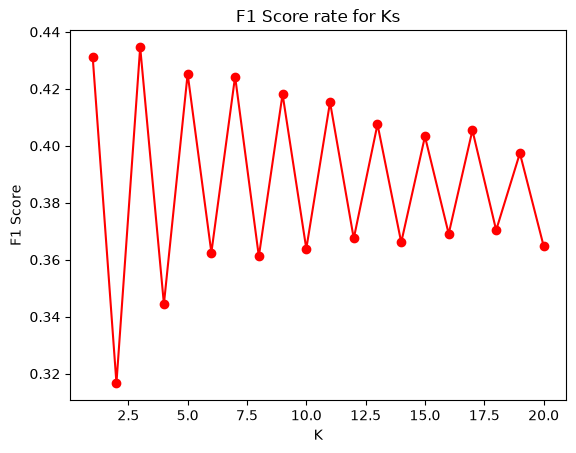

In [11]:
list_of_score = []
for index in range(1, 21):
    _knn = KNeighborsClassifier(n_neighbors=index)
    _knn.fit(X_train, Y_train)
    
    y_pred = _knn.predict(X_test)
    _score = f1_score(Y_test, y_pred)
    list_of_score.append(_score)

plt.plot(list(range(1, 21)), list_of_score, color="red", marker='o')
plt.xlabel("K")
plt.ylabel("F1 Score")
plt.title("F1 Score rate for Ks")
plt.show()



حالا که لیست خروجی برای ک های مختلف رو داریم آرگومان مقداری که درصد فیتش بیشترینه رو حساب میکنیم(ک ای که به ازای اون بهترین فیت طبق الگوربتم اف 1 انجام میگیره)

In [12]:
scores = np.array(list_of_score)
max_index = np.argmax(scores) + 1
print(f"Optimal K: {max_index}")

Optimal K: 3


حالا مقدار درصد رو بر اساس الگوریتم اف 1 نمایش میدیم

In [13]:
knn = KNeighborsClassifier(n_neighbors=max_index)
knn.fit(X_train, Y_train)

final_pred = knn.predict(X_test)
final_f1 = f1_score(Y_test, final_pred)
print(f"Final F1 Score: {final_f1}")

Final F1 Score: 0.4346435960127892


## بخش ج

برای پیش‌بینی بلادرنگ ، الگوریتم درخت تصمیم بسیار مناسب‌تر است.

**دلیل:**
درخت تصمیم یک مدل «یادگیرنده مشتاق» است؛ یعنی مدل از قبل آموزش دیده و در زمان پیش‌بینی، فقط باید چند شرط ساده (اگر-آنگاه) را دنبال کند که بسیار سریع است. 

در مقابل، الگوریتم «همسایگان نزدیک» یک «یادگیرنده تنبل» است؛ یعنی در زمان پیش‌بینی، باید فاصله داده جدید را با تک‌تک داده‌های آموزشی محاسبه کند که این کار باعث ایجاد تأخیر زیاد شده و برای پاسخ‌دهی در کوتاه‌ترین زمان ممکن، کارایی لازم را ندارد.